# Analysis of sentences

## 1. Read data

In [1]:
import pandas as pd
sentence_df = pd.read_excel("/workspace/mijnidbcoachnlp/data/analysis_datasets/translated_sentence_data.xlsx")

In [2]:
# clean sentences as inputs
sentences = sentence_df["Clean_Sentence"].to_list()

In [352]:
sentence_df

,Message_ID,Sentence,Clean_Sentence,Sentence_ID,Translated_Sentence
0,3,Ik ben 2 weken geleden met spoed opgenomen in het [PERSOON-1] in [LOCATIE-1] met verdenking van hartklachten.,Ik ben 2 weken geleden met spoed opgenomen in het in met verdenking van hartklachten.,0,I was rushed into the [PRESSION-1] [LOCATION-1] two weeks ago with suspicion of heart problems.
1,3,"Ik kreeg acuut een pijnlijke druk op de borst, schouderbladen, uitstralend naar de armen.","Ik kreeg acuut een pijnlijke druk op de borst, schouderbladen, uitstralend naar de armen.",1,"I was acutely under a painful pressure on the chest, shoulder blades, radiating to the arms."
2,3,Het begon 1 uur na het avondeten.,Het begon 1 uur na het avondeten.,2,It started 1 hour after dinner.
3,3,"Ik had al de hele dag migraine, had dus ook weinig gegeten.","Ik had al de hele dag migraine, had dus ook weinig gegeten.",3,"I had migraines all day, so I hadn't eaten much."
4,3,"Ik werd heel erg misselijk, braakneigingen, duizelig en oprispingen.En vreselijke pijn.","Ik werd heel erg misselijk, braakneigingen, duizelig en oprispingen.En vreselijke pijn.",4,"I got very nauseous, vomiting, dizzy and rejuvenating, and terrible pain."
...,...,...,...,...,...
42532,33229,"Ze hebben de urine op kweek gezet, kan morgenvroeg de uitslag krijgen hiervan.","Ze hebben de urine op kweek gezet, kan morgenvroeg de uitslag krijgen hiervan.",42532,"They've put the urine on culture, can get the results of this in the morning."
42533,33229,Afgelopen jaren is er al vaker bloed in mijn urine gevonden en ik vraag me af of het iets te maken heeft met de ziekte v Crohn of een fist oid?,Afgelopen jaren is er al vaker bloed in mijn urine gevonden en ik vraag me af of het iets te maken heeft met de ziekte v Crohn of een fist oid?,42533,"In recent years, blood has been found in my urine and I wonder if it has anything to do with the disease v Crohn or a fist oid?"
42534,33229,Wat adviseert u hiermee te doen?,Wat adviseert u hiermee te doen?,42534,What do you suggest you do with this?
42535,33231,"Hoi [PERSOON-1], Oke, dat is iig al een geruststelling ;) ik wacht de uitslag even af verder.","Oke, dat is iig al een geruststelling ;) ik wacht de uitslag even af verder.",42535,"Hi [PRESSON-1], Okay, that's a relief;) I'll wait for the results."


## 2. Embed the lists of sentences with sentence-transformer multilingual-v1

In [3]:
from sentence_transformers import SentenceTransformer
import numpy as np

# Precalculating multilingual embeddings
# embedding model 1
embedding_model_st_v1 = SentenceTransformer("distiluse-base-multilingual-cased-v1")

# run the following for embeddings if no pre-saved embeddings can be loaded
#embeddings_mv1 = embedding_model_st_v1.encode(sentences, show_progress_bar=True)
# save the pre-calculated embeddings 
#np.save('/workspace/mijnidbcoachnlp/data/embeddings/embeddings_st_v1.npy', embeddings_mv1)

/workspace/.venv/lib/python3.8/site-packages/sentence_transformers/cross_encoder/CrossEncoder.py:13: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


In [4]:
import numpy as np

# load pre-saved embeddings
embeddings = np.load("/workspace/mijnidbcoachnlp/data/embeddings/embeddings_st_v1.npy")
embedding_model = embedding_model_st_v1

In [5]:
### Importing the list of Dutch stopwords (note that there are customized dutch words in there)

with open('/workspace/mijnidbcoachnlp/data/analysis_datasets/stopwords.txt', 'r') as file:
    lines = [line.strip() for line in file.readlines()]

dutch_stopwords = lines

extra_list = [
    'maandag', 'dinsdag', 'woensdag', 'donderdag', 'vrijdag', 'zaterdag', 'zondag',
    'januari', 'februari', 'maart', 'april', 'mei', 'juni', 'juli', 'augustus', 'september', 'oktober', 'november', 'december',
    'jan', 'feb', 'mrt', 'apr', 'mei', 'jun', 'jul', 'aug', 'sep', 'okt', 'nov', 'dec', "jl", "weken", "week", "dagen", "dag", "mg"
]

dutch_stopwords.extend(extra_list)

## 3. Preparation for model evaluation

### 3.1 Import the annotated set

In [264]:
annotated_df = pd.read_excel("/workspace/mijnidbcoachnlp/data/analysis_datasets/sample_sentences_for_labeling_100.xlsx", index_col=0)

In [7]:
annotated_df

,Message_ID,Sentence,Clean_Sentence,Sentence_ID,Translated_Sentence,Manual_Label
269,173,"Beste [PERSOON-1], het gaat weer iets beter ...",het gaat weer iets beter en ik heb gisteren de...,269,"Dear [PERSOON-1], things are getting better an...",A7
270,173,Het liep goed totdat ik probeerde de onderkant...,Het liep goed totdat ik probeerde de onderkant...,270,It went well until I tried to break the bottom...,A7
271,173,Ik kreeg het niet voor elkaar en heb toen meer...,Ik kreeg het niet voor elkaar en heb toen meer...,271,I couldn't do it and then I used more power.,A9
272,173,Hij lijkt me nu op de verkeerde plek gebroken ...,j lijkt me nu op de verkeerde plek gebroken (z...,272,It looks like it's broken in the wrong place (...,A9
273,173,De test is uiteindelijk mislukt volgens de app.,De test is uiteindelijk mislukt volgens de app.,273,The test ultimately failed according to the app.,A1
...,...,...,...,...,...,...
42370,33048,"Omdat ik aangaf dat het echt niet goed ging, h...","Omdat ik aangaf dat het echt niet goed ging, h...",42370,"Because I indicated that it was really bad, sh...",M5
42371,33048,De dienstdoendearts gaf aan dat de echo goed w...,De dienstdoendearts gaf aan dat de echo goed w...,42371,The medical examiner indicated that the ultras...,A8
42519,33204,"Hoi [PERSOON-1], Dank voor je snelle reactie:...",Dank voor je snelle reactie:) Ik zal een zelf...,42519,"Hi [PRESSON-1], Thank you for your quick react...",A7
42520,33204,"Dank voor de afspraak in september, staat geno...","Dank voor de afspraak in september, staat geno...",42520,"Thanks for the September appointment, it's noted.",A2


### 3.2 Function to build a BERTopic model

In [8]:
# set the vectorizer model
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
from hdbscan import HDBSCAN
from bertopic.vectorizers import ClassTfidfTransformer
from bertopic.representation import KeyBERTInspired
from umap import UMAP

# configure the sub-models
#vectorizer
vectorizer_model=CountVectorizer(stop_words=dutch_stopwords, min_df=2, ngram_range=(1, 2), token_pattern=r'\b[a-zA-Z]{3,}\b')
# clustering (3 options)
hdb_model = HDBSCAN(min_cluster_size=20, min_samples=10, metric='euclidean', cluster_selection_method='eom', prediction_data=True)
kmeans_model = KMeans(n_clusters=100)
agglo_model = AgglomerativeClustering(n_clusters=100)
# dimension reduction
umap_model=UMAP(n_neighbors=10, n_components=2, metric='cosine', random_state=42)
ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)
representation_model = KeyBERTInspired()


In [9]:
# function to build the model with different selection of clustering method
# build the BERTopic model
from bertopic import BERTopic
from bertopic import BERTopic

def build_bertopic():
    cluster_model=hdb_model
    # Initialize BERTopic with UMAP and HDBSCAN models
    topic_model = BERTopic(
        embedding_model=embedding_model,
        umap_model=umap_model,
        hdbscan_model=cluster_model,
        #vectorizer_model=CountVectorizer(stop_words=dutch_stopwords, min_df=2, ngram_range=(1, 2), token_pattern=r'\b[a-zA-Z]{3,}\b'),
        top_n_words=10,
        verbose=True
    )

    # Fit-transform to get document topics and probabilities
    topics, probs = topic_model.fit_transform(sentences, embeddings)
    

    # Return only essential results
    return topic_model

## 4. SBERT V1 + HDBSCAN

In [10]:
topic_model = build_bertopic()

2024-11-18 14:24:52,024 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2024-11-18 14:26:05,210 - BERTopic - Dimensionality - Completed ✓
2024-11-18 14:26:05,216 - BERTopic - Cluster - Start clustering the reduced embeddings
2024-11-18 14:26:08,047 - BERTopic - Cluster - Completed ✓
2024-11-18 14:26:08,065 - BERTopic - Representation - Extracting topics from clusters using representation models.
2024-11-18 14:26:09,075 - BERTopic - Representation - Completed ✓


In [11]:
# Reduce outliers
topics = topic_model.topics_
new_topics = topic_model.reduce_outliers(sentences, topics)

100%|██████████| 16/16 [00:03<00:00,  4.86it/s]


In [12]:
topic_model.update_topics(sentences, topics=new_topics)

2024-11-18 14:26:14,461 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


In [13]:
vectorizer_model=CountVectorizer(stop_words=dutch_stopwords, min_df=2, ngram_range=(1, 2), token_pattern=r'\b[a-zA-Z]{3,}\b')
topic_model.update_topics(sentences, vectorizer_model=vectorizer_model)
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2,-1_paarse___,"[paarse, , , , , , , , , ]",[Ik vroeg me af of dit met de medicatie te mak...
1,0,3622,0_bloed_prikken_bloed laten_laten prikken,"[bloed, prikken, bloed laten, laten prikken, b...",[Op heb ik bloed laten prikken en ontlasting ...
2,1,1804,1_uur_afspraak_gepland_afspraak staan,"[uur, afspraak, gepland, afspraak staan, endos...","[en , Ik heb een afspraak met op Maandag om..."
3,2,745,2_test_testen_test gedaan_quanton,"[test, testen, test gedaan, quanton, cal, quan...","[Ik zal een test doen., Zal ik doen ,ik heb no..."
4,3,659,3_pijn_buikpijn_hoofdpijn_pijnlijk,"[pijn, buikpijn, hoofdpijn, pijnlijk, buik, pi...","[Pijn is al wat minder., Maar ik heb af en toe..."
...,...,...,...,...,...
285,284,46,284_bedankt reactie_reactie bedankt_reactie_be...,"[bedankt reactie, reactie bedankt, reactie, be...","[Bedankt voor je reactie., Bedankt voor je rea..."
286,285,24,285_mededeling_bedankt bericht_bericht bedankt...,"[mededeling, bedankt bericht, bericht bedankt,...","[Bedankt voor het bericht., Bedankt voor het b..."
287,286,62,286_medicijn_bestellen_medicijn bestellen_volg...,"[medicijn, bestellen, medicijn bestellen, volg...",[ik wil graag het volgende medicijn bestellen....
288,287,20,287_graag hoor_hoor graag_hoor_graag,"[graag hoor, hoor graag, hoor, graag, julie, ,...","[Graag hoor ik van jullie., Graag hoor ik van ..."


In [14]:
# save the model after outlier reduction
topic_model.save("/workspace/mijnidbcoachnlp/data/result_data/saved_ST_model_reduced_outliers", serialization="pytorch", save_ctfidf=True, save_embedding_model=embedding_model)

### 4.2 Merging topics with hierarchy

In [143]:
hierarchical_topics = topic_model.hierarchical_topics(sentences)
topic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics)

100%|██████████| 23/23 [00:00<00:00, 130.52it/s]


In [158]:
#save the topic info
topic_info = topic_model.get_topic_info()
topic_info["Name"].to_list()

['-1_bedankt_dank_hoor_reactie',
 '0_bloed_ontlasting_prikken_laten',
 '1_afspraak_contact_telefonisch_vandaag',
 '2_pijn_last_buikpijn_klachten',
 '3_medicatie_gebruik_tabletten_humira',
 '4_voel_goed_beter_gaat',
 '5_recept_apotheek_nieuw_nieuw recept',
 '6_ontvangen_formulieren_brief_formulier',
 '7_huisarts_arts_dokter_dermatoloog',
 '8_advies_probleem_graag advies_zorgen',
 '9_mri_onderzoek_scan_mri scan',
 '10_corona_vaccin_vaccinatie_oproep',
 '11_eten_eet_energie_gewicht',
 '12_zwanger_zwangerschap_borstvoeding_weet',
 '13_werk_werken_werk werk_ivm werk',
 '14_operatie_chirurg_wachtlijst_plaatsvinden']

In [159]:
#save the topic info
doc_info = topic_model.get_document_info(sentences)
doc_info.to_csv('/workspace/mijnidbcoachnlp/data/result_data/doc_info_st_merged.csv', index=False)

In [162]:
topic_info.to_csv('/workspace/mijnidbcoachnlp/data/result_data/topic_info_st_merged.csv', index=False)

In [163]:
topic_info

,Topic,Count,Name,Representation,Representative_Docs
0,-1,8722,-1_bedankt_dank_hoor_reactie,"[bedankt, dank, hoor, reactie, graag, hoor graag, alvast, snelle, vraag, weet]","[Alvast bedankt voor jullie reactie., Alvast bedankt voor de reactie., Alvast bedankt voor jullie reactie]"
1,0,5968,0_bloed_ontlasting_prikken_laten,"[bloed, ontlasting, prikken, laten, bloed laten, laten prikken, test, uitslag, bloed ontlasting, bekend]","[ik heb ongeveer 2 weken geleden bloed laten prikken., Ben op in kerkrade geweest voor bloed te laten prikken., Ik heb 2 april weer bloed laten prikken in helmond.]"
2,1,5784,1_afspraak_contact_telefonisch_vandaag,"[afspraak, contact, telefonisch, vandaag, morgen, poli, vakantie, bellen, uur, gepland]","[9 Mei afspraak bij Dr,, afspraak is inmiddels binnen., Maandag afspraak met D’r.]"
3,2,4690,2_pijn_last_buikpijn_klachten,"[pijn, last, buikpijn, klachten, toilet, crohn, ontlasting, keer, buik, merk]","[Verder eigenlijk geen last van buikpijn gehad, nu een beetje maar meer eigenlijk een beetje pijn aan de onderbuik waar de darm loopt dan echte buikpijn., Geen crohn pijn., Geen pijn meer in.]"
4,3,4361,3_medicatie_gebruik_tabletten_humira,"[medicatie, gebruik, tabletten, humira, antibiotica, gebruiken, medicijnen, mee, apotheek, medicijn]","[Ja ik gebruik 2x2 mezant per dag., Mijn medicatie is bijna op., Mijn medicatie is bijna op.]"
5,4,3472,4_voel_goed_beter_gaat,"[voel, goed, beter, gaat, vorige, jaar, laatste, maanden, gelukkig, maand]","[Dus dat is goed., Ik voel mij redelijk goed !, En het gaat gelukkig weer beter.]"
6,5,2244,5_recept_apotheek_nieuw_nieuw recept,"[recept, apotheek, nieuw, nieuw recept, sturen, graag, herhaalrecept, zorginstelling, recept apotheek, sturen apotheek]","[En zo ja, zou hier dan een nieuw recept voor kunnen worden gestuurd naar mijn apotheek ([ZIEKENHUIS] )?, Willen jullie een nieuw recept voor de B12-spuiten naar de apotheek sturen., een nieuw recept naar de apotheek sturen.]"
7,6,2148,6_ontvangen_formulieren_brief_formulier,"[ontvangen, formulieren, brief, formulier, mail, app, bericht, potje, gehoord, foto]","[Ik heb niets ontvangen namelijk., Heb nog niets ontvangen., Ik heb het formulier voor de calprotectine ontvangen.]"
8,7,1485,7_huisarts_arts_dokter_dermatoloog,"[huisarts, arts, dokter, dermatoloog, ziekenhuis, mdl, mdl arts, afspraak, huid, dermatologie]","[Mijn eigen arts was er niet., Ik ben net bij de huisarts geweest., Volgens de huisarts heb ik ze gehad in '89.]"
9,8,1400,8_advies_probleem_graag advies_zorgen,"[advies, probleem, graag advies, zorgen, zitten, idee, helpen, graag, mis, adviseren]","[Graag jullie advies., Wil graag advies, Graag jullie advies.]"


In [164]:
# Manually Put Labels in the Label Column
# Create the customized label column
topic_info["Label"] = None

In [165]:
topic_info.to_excel('/workspace/mijnidbcoachnlp/data/result_data/final_topic_info_st.xlsx', index=False)

In [222]:
labeled_topic_info = pd.read_excel('/workspace/mijnidbcoachnlp/data/result_data/merged_topic_info_st_labeld.xlsx')

In [306]:
topic_names = ["Other", "Test Procedure & Results", "Appointment/Contact", "Symptoms", "Medication", "General Health Update",
                "Pharmacy", "Administrative Communication", "Consultation/Hospital Visit", "Medical Advice/Discussion", "Medical Examination",
                "Vaccination & Immunity", "Diet & Weight", "Pregnancy", "Work-Related Disease Management", "Surgery/Operation"]

In [310]:
labeled_topic_info["Label_Name"] = topic_names
labeled_topic_info

,Topic,Count,Name,Representation,Representative_Docs,Label,Label_Name
0,-1,8722,-1_bedankt_dank_hoor_reactie,"['bedankt', 'dank', 'hoor', 'reactie', 'graag', 'hoor graag', 'alvast', 'snelle', 'vraag', 'weet']","['Alvast bedankt voor jullie reactie.', 'Alvast bedankt voor de reactie.', 'Alvast bedankt voor jullie reactie']",A5,Other
1,0,5968,0_bloed_ontlasting_prikken_laten,"['bloed', 'ontlasting', 'prikken', 'laten', 'bloed laten', 'laten prikken', 'test', 'uitslag', 'bloed ontlasting', 'bekend']","['ik heb ongeveer 2 weken geleden bloed laten prikken.', 'Ben op in kerkrade geweest voor bloed te laten prikken.', 'Ik heb 2 april weer bloed laten prikken in helmond.']",A4,Test Procedure & Results
2,1,5784,1_afspraak_contact_telefonisch_vandaag,"['afspraak', 'contact', 'telefonisch', 'vandaag', 'morgen', 'poli', 'vakantie', 'bellen', 'uur', 'gepland']","['9 Mei afspraak bij Dr,', 'afspraak is inmiddels binnen.', 'Maandag afspraak met D’r.']",A2,Appointment/Contact
3,2,4690,2_pijn_last_buikpijn_klachten,"['pijn', 'last', 'buikpijn', 'klachten', 'toilet', 'crohn', 'ontlasting', 'keer', 'buik', 'merk']","['Verder eigenlijk geen last van buikpijn gehad, nu een beetje maar meer eigenlijk een beetje pijn aan de onderbuik waar de darm loopt dan echte buikpijn.', 'Geen crohn pijn.', 'Geen pijn meer in.']",M8,Symptoms
4,3,4361,3_medicatie_gebruik_tabletten_humira,"['medicatie', 'gebruik', 'tabletten', 'humira', 'antibiotica', 'gebruiken', 'medicijnen', 'mee', 'apotheek', 'medicijn']","['Ja ik gebruik 2x2 mezant per dag.', 'Mijn medicatie is bijna op.', 'Mijn medicatie is bijna op.']",M6,Medication
5,4,3472,4_voel_goed_beter_gaat,"['voel', 'goed', 'beter', 'gaat', 'vorige', 'jaar', 'laatste', 'maanden', 'gelukkig', 'maand']","['Dus dat is goed.', 'Ik voel mij redelijk goed !', 'En het gaat gelukkig weer beter.']",M3,General Health Update
6,5,2244,5_recept_apotheek_nieuw_nieuw recept,"['recept', 'apotheek', 'nieuw', 'nieuw recept', 'sturen', 'graag', 'herhaalrecept', 'zorginstelling', 'recept apotheek', 'sturen apotheek']","['En zo ja, zou hier dan een nieuw recept voor kunnen worden gestuurd naar mijn apotheek ([ZIEKENHUIS] )?', 'Willen jullie een nieuw recept voor de B12-spuiten naar de apotheek sturen.', 'een nieuw recept naar de apotheek sturen.']",A3,Pharmacy
7,6,2148,6_ontvangen_formulieren_brief_formulier,"['ontvangen', 'formulieren', 'brief', 'formulier', 'mail', 'app', 'bericht', 'potje', 'gehoord', 'foto']","['Ik heb niets ontvangen namelijk.', 'Heb nog niets ontvangen.', 'Ik heb het formulier voor de calprotectine ontvangen.']",A1,Administrative Communication
8,7,1485,7_huisarts_arts_dokter_dermatoloog,"['huisarts', 'arts', 'dokter', 'dermatoloog', 'ziekenhuis', 'mdl', 'mdl arts', 'afspraak', 'huid', 'dermatologie']","['Mijn eigen arts was er niet.', 'Ik ben net bij de huisarts geweest.', ""Volgens de huisarts heb ik ze gehad in '89.""]",M2,Consultation/Hospital Visit
9,8,1400,8_advies_probleem_graag advies_zorgen,"['advies', 'probleem', 'graag advies', 'zorgen', 'zitten', 'idee', 'helpen', 'graag', 'mis', 'adviseren']","['Graag jullie advies.', 'Wil graag advies', 'Graag jullie advies.']",M4,Medical Advice/Discussion


In [379]:
data = labeled_topic_info[["Count", "Label_Name"]][1:]
data

,Count,Label_Name
1,5968,Test Procedure & Results
2,5784,Appointment/Contact
3,4690,Symptoms
4,4361,Medication
5,3472,General Health Update
6,2244,Pharmacy
7,2148,Administrative Communication
8,1485,Consultation/Hospital Visit
9,1400,Medical Advice/Discussion
10,638,Medical Examination


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

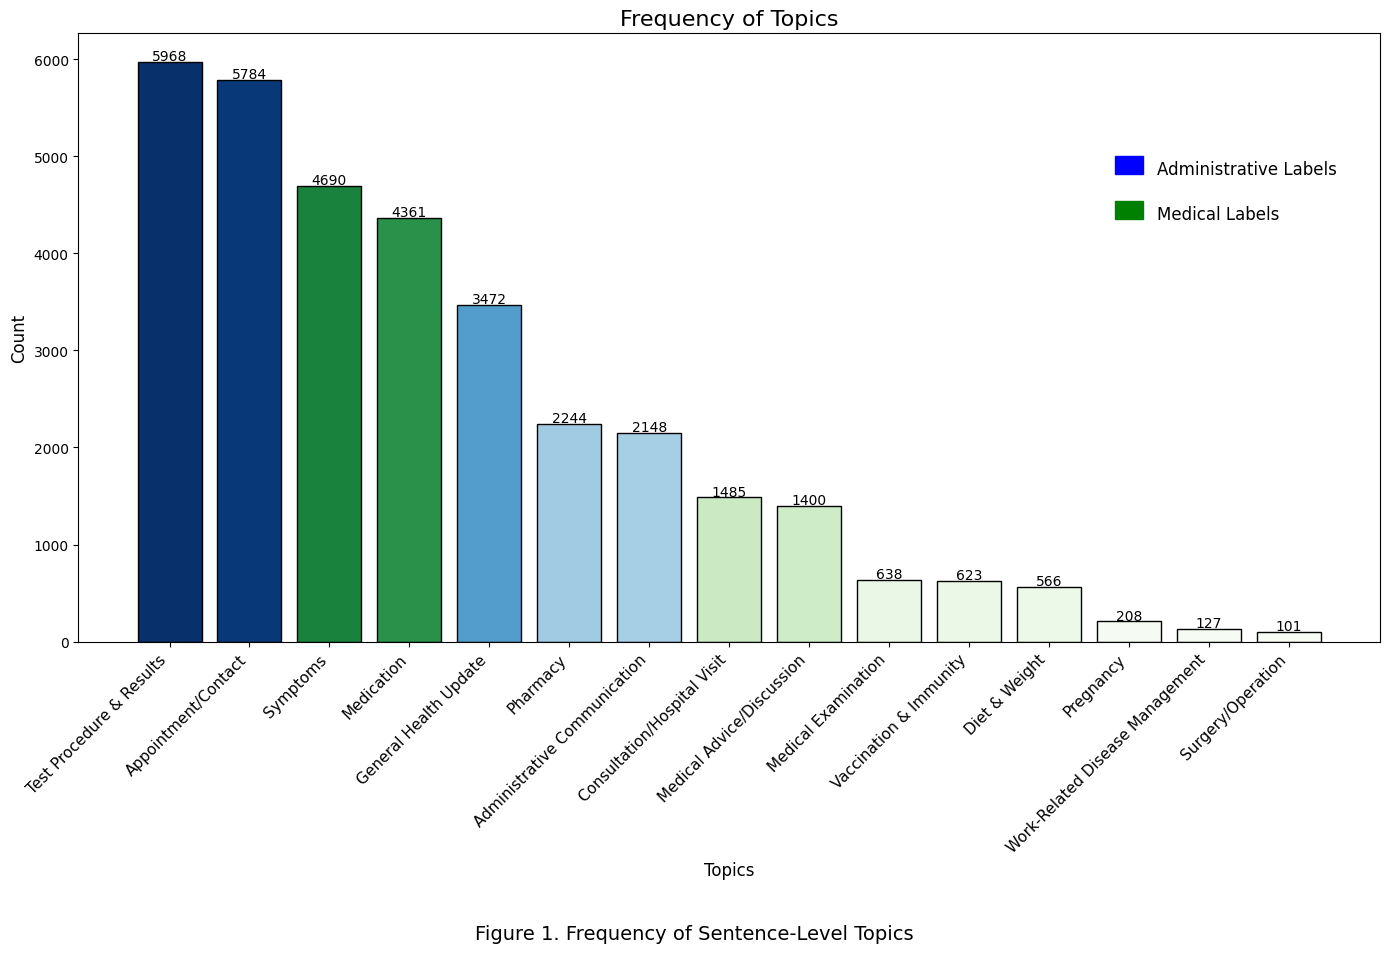

In [393]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Select the relevant columns
data = labeled_topic_info[["Count", "Label_Name"]][1:]

# Sort the DataFrame by "Count" in descending order for better visualization
data = data.sort_values(by="Count", ascending=False).reset_index(drop=True)

# Normalize the counts to create a gradient effect
normalized_counts = (data["Count"] - data["Count"].min()) / (data["Count"].max() - data["Count"].min())

# Define two colormaps: Blue for administrative labels, Green for medical labels
blue_colors = plt.cm.Blues(normalized_counts)  # Administrative labels
green_colors = plt.cm.Greens(normalized_counts)  # Medical labels

# Specify which labels are administrative (blue)
administrative_labels = ["Test Procedure & Results", "Appointment/Contact", 
                         "General Health Update", "Pharmacy", "Administrative Communication"]

# Dynamically assign colors
colors = [blue_colors[i] if label in administrative_labels else green_colors[i] 
          for i, label in enumerate(data["Label_Name"])]

# Create the bar chart
plt.figure(figsize=(14, 9))
bars = plt.bar(data["Label_Name"], data["Count"], color=colors, edgecolor="black")

# Add count labels above the bars with an extended distance
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 20, int(yval), ha="center", fontsize=10)

# Add titles and labels
plt.title("Frequency of Topics", fontsize=16)
plt.xlabel("Topics", fontsize=12)
plt.ylabel("Count", fontsize=12)

# Add a caption below the x-axis label
plt.figtext(0.5, -0.05, "Figure 1. Frequency of Sentence-Level Topics", 
            wrap=True, horizontalalignment="center", fontsize=14)

# Move the custom legend slightly to the left
plt.gca().add_patch(mpatches.Rectangle((0.8, 0.8), 0.02, 0.02, color="blue", transform=plt.gcf().transFigure, clip_on=False))
plt.figtext(0.83, 0.8, "Administrative Labels", fontsize=12, color="black", ha="left")

plt.gca().add_patch(mpatches.Rectangle((0.8, 0.75), 0.02, 0.02, color="green", transform=plt.gcf().transFigure, clip_on=False))
plt.figtext(0.83, 0.75, "Medical Labels", fontsize=12, color="black", ha="left")

# Rotate x-axis labels for readability
plt.xticks(rotation=45, fontsize=11, ha="right")

# Adjust layout to avoid clipping
plt.tight_layout()

# Show the plot
plt.show()


In [224]:
merged_doc_info = topic_model.get_document_info(sentences)
merged_doc_info.to_excel('/workspace/mijnidbcoachnlp/data/result_data/merged_doc_info_st.xlsx', index=False)

In [263]:
merged_doc_info["Sentence_ID"] = merged_doc_info.index
merged_doc_info[merged_doc_info["Topic"] == 3]

,Document,Topic,Name,Representation,Representative_Docs,Top_n_words,Probability,Representative_document,Sentence_ID
27,`paracetamol helpt niiet.,3,3_medicatie_gebruik_tabletten_humira,"[medicatie, gebruik, tabletten, humira, antibiotica, gebruiken, medicijnen, mee, apotheek, medicijn]","[Ja ik gebruik 2x2 mezant per dag., Mijn medicatie is bijna op., Mijn medicatie is bijna op.]",medicatie - gebruik - tabletten - humira - antibiotica - gebruiken - medicijnen - mee - apotheek - medicijn,0.000000,False,27
37,En paracetamol helpt niet.,3,3_medicatie_gebruik_tabletten_humira,"[medicatie, gebruik, tabletten, humira, antibiotica, gebruiken, medicijnen, mee, apotheek, medicijn]","[Ja ik gebruik 2x2 mezant per dag., Mijn medicatie is bijna op., Mijn medicatie is bijna op.]",medicatie - gebruik - tabletten - humira - antibiotica - gebruiken - medicijnen - mee - apotheek - medicijn,0.000000,False,37
44,Ik slik momenteel geen medicatie.,3,3_medicatie_gebruik_tabletten_humira,"[medicatie, gebruik, tabletten, humira, antibiotica, gebruiken, medicijnen, mee, apotheek, medicijn]","[Ja ik gebruik 2x2 mezant per dag., Mijn medicatie is bijna op., Mijn medicatie is bijna op.]",medicatie - gebruik - tabletten - humira - antibiotica - gebruiken - medicijnen - mee - apotheek - medicijn,0.000000,False,44
58,"Ik heb een vragen lijst hier gekregen over het medicijn, Biological.",3,3_medicatie_gebruik_tabletten_humira,"[medicatie, gebruik, tabletten, humira, antibiotica, gebruiken, medicijnen, mee, apotheek, medicijn]","[Ja ik gebruik 2x2 mezant per dag., Mijn medicatie is bijna op., Mijn medicatie is bijna op.]",medicatie - gebruik - tabletten - humira - antibiotica - gebruiken - medicijnen - mee - apotheek - medicijn,0.816588,False,58
70,moet ik deze nu wel of niet invullen ?,3,3_medicatie_gebruik_tabletten_humira,"[medicatie, gebruik, tabletten, humira, antibiotica, gebruiken, medicijnen, mee, apotheek, medicijn]","[Ja ik gebruik 2x2 mezant per dag., Mijn medicatie is bijna op., Mijn medicatie is bijna op.]",medicatie - gebruik - tabletten - humira - antibiotica - gebruiken - medicijnen - mee - apotheek - medicijn,1.000000,False,70
...,...,...,...,...,...,...,...,...,...
42511,"Ik heb een paar vraagjes rondom het gebruik van Humira/Hyrimoz: - Ik zag dat de nieuwe Hyrimoz pennen hetzelfde aantal mg hebben als de Humira pennen, maar wel dubbele aantal ml.",3,3_medicatie_gebruik_tabletten_humira,"[medicatie, gebruik, tabletten, humira, antibiotica, gebruiken, medicijnen, mee, apotheek, medicijn]","[Ja ik gebruik 2x2 mezant per dag., Mijn medicatie is bijna op., Mijn medicatie is bijna op.]",medicatie - gebruik - tabletten - humira - antibiotica - gebruiken - medicijnen - mee - apotheek - medicijn,0.788567,False,42511
42522,Ik gebruik op het moment Pentasa Compact 4g .,3,3_medicatie_gebruik_tabletten_humira,"[medicatie, gebruik, tabletten, humira, antibiotica, gebruiken, medicijnen, mee, apotheek, medicijn]","[Ja ik gebruik 2x2 mezant per dag., Mijn medicatie is bijna op., Mijn medicatie is bijna op.]",medicatie - gebruik - tabletten - humira - antibiotica - gebruiken - medicijnen - mee - apotheek - medicijn,0.000000,False,42522
42524,Ik gebruik op het moment Pentasa Compact 4g .,3,3_medicatie_gebruik_tabletten_humira,"[medicatie, gebruik, tabletten, humira, antibiotica, gebruiken, medicijnen, mee, apotheek, medicijn]","[Ja ik gebruik 2x2 mezant per dag., Mijn medicatie is bijna op., Mijn medicatie is bijna op.]",medicatie - gebruik - tabletten - humira - antibiotica - gebruiken - medicijnen - mee - apotheek - medicijn,0.000000,False,42524
42526,Ik gebruik op het moment Pentasa Compact 4g .,3,3_medicatie_gebruik_tabletten_humira,"[medicatie, gebruik, tabletten, humira, antibiotica, gebruiken, medicijnen, mee, apotheek, medicijn]","[Ja ik gebruik 2x2 mezant per dag., Mijn medicatie is bijna op., Mijn medicatie is bijna op.]",medicatie - gebruik - tabletten - humira - antibiotica - gebruiken - medicijnen - mee - apotheek - medicijn,0.000000,False,42526


In [265]:
annotated_df['Sentence_ID'] = annotated_df['Sentence_ID'].astype(str)
merged_doc_info['Sentence_ID'] = merged_doc_info['Sentence_ID'].astype(str)

In [266]:
# Now perform the merge
annotated_df = pd.merge(
    annotated_df,
    merged_doc_info[['Sentence_ID', 'Topic', 'Top_n_words']],
    on='Sentence_ID',
    how='left'
)

In [267]:
annotated_df.head(5)

,Message_ID,Sentence,Clean_Sentence,Sentence_ID,Translated_Sentence,Manual_Label,Topic,Top_n_words
0,173,"Beste [PERSOON-1], het gaat weer iets beter en ik heb gisteren de test proberen te doen.",het gaat weer iets beter en ik heb gisteren de test proberen te doen.,269,"Dear [PERSOON-1], things are getting better and I tried to do the test yesterday.",A4,0,bloed - ontlasting - prikken - laten - bloed laten - laten prikken - test - uitslag - bloed ontlasting - bekend
1,173,Het liep goed totdat ik probeerde de onderkant van het buisje te breken.,Het liep goed totdat ik probeerde de onderkant van het buisje te breken.,270,It went well until I tried to break the bottom of the tube.,A4,0,bloed - ontlasting - prikken - laten - bloed laten - laten prikken - test - uitslag - bloed ontlasting - bekend
2,173,Ik kreeg het niet voor elkaar en heb toen meer kracht gebruikt.,Ik kreeg het niet voor elkaar en heb toen meer kracht gebruikt.,271,I couldn't do it and then I used more power.,A5,1,afspraak - contact - telefonisch - vandaag - morgen - poli - vakantie - bellen - uur - gepland
3,173,Hij lijkt me nu op de verkeerde plek gebroken (zie foto).,j lijkt me nu op de verkeerde plek gebroken (zie foto).,272,It looks like it's broken in the wrong place (see picture).,A5,8,advies - probleem - graag advies - zorgen - zitten - idee - helpen - graag - mis - adviseren
4,173,De test is uiteindelijk mislukt volgens de app.,De test is uiteindelijk mislukt volgens de app.,273,The test ultimately failed according to the app.,A4,0,bloed - ontlasting - prikken - laten - bloed laten - laten prikken - test - uitslag - bloed ontlasting - bekend


In [268]:
annotated_df = pd.merge(
    annotated_df,
    labeled_topic_info[['Topic', 'Label']],
    on='Topic',
    how='left'
)

In [269]:
annotated_df[:20]

,Message_ID,Sentence,Clean_Sentence,Sentence_ID,Translated_Sentence,Manual_Label,Topic,Top_n_words,Label
0,173,"Beste [PERSOON-1], het gaat weer iets beter en ik heb gisteren de test proberen te doen.",het gaat weer iets beter en ik heb gisteren de test proberen te doen.,269,"Dear [PERSOON-1], things are getting better and I tried to do the test yesterday.",A4,0,bloed - ontlasting - prikken - laten - bloed laten - laten prikken - test - uitslag - bloed ontlasting - bekend,A4
1,173,Het liep goed totdat ik probeerde de onderkant van het buisje te breken.,Het liep goed totdat ik probeerde de onderkant van het buisje te breken.,270,It went well until I tried to break the bottom of the tube.,A4,0,bloed - ontlasting - prikken - laten - bloed laten - laten prikken - test - uitslag - bloed ontlasting - bekend,A4
2,173,Ik kreeg het niet voor elkaar en heb toen meer kracht gebruikt.,Ik kreeg het niet voor elkaar en heb toen meer kracht gebruikt.,271,I couldn't do it and then I used more power.,A5,1,afspraak - contact - telefonisch - vandaag - morgen - poli - vakantie - bellen - uur - gepland,A2
3,173,Hij lijkt me nu op de verkeerde plek gebroken (zie foto).,j lijkt me nu op de verkeerde plek gebroken (zie foto).,272,It looks like it's broken in the wrong place (see picture).,A5,8,advies - probleem - graag advies - zorgen - zitten - idee - helpen - graag - mis - adviseren,M4
4,173,De test is uiteindelijk mislukt volgens de app.,De test is uiteindelijk mislukt volgens de app.,273,The test ultimately failed according to the app.,A4,0,bloed - ontlasting - prikken - laten - bloed laten - laten prikken - test - uitslag - bloed ontlasting - bekend,A4
5,173,Waar moet het buisje breken en hoe krijg ik dit het beste voor elkaar?,Waar moet het buisje breken en hoe krijg ik dit het beste voor elkaar?,274,Where do I break the tube and how do I do it best?,A4,-1,bedankt - dank - hoor - reactie - graag - hoor graag - alvast - snelle - vraag - weet,A5
6,173,Kan ik nog een of twee nieuwe testen krijgen?,Kan ik nog een of twee nieuwe testen krijgen?,275,Can I get one or two more tests?,A4,0,bloed - ontlasting - prikken - laten - bloed laten - laten prikken - test - uitslag - bloed ontlasting - bekend,A4
7,658,"Beste [PERSOON-1], Is het dan een idee dat ik eerst een afspraak maak bij de huisarts en dan zelf eventueel een verwijzing maak?",Is het dan een idee dat ik eerst een afspraak maak bij de huisarts en dan zelf eventueel een verwijzing maak?,886,"Dear [PERSOON-1], is it an idea that I first make an appointment with the general practitioner and then make a referral myself?",A2,7,huisarts - arts - dokter - dermatoloog - ziekenhuis - mdl - mdl arts - afspraak - huid - dermatologie,M2
8,658,Dus dat de afsprak bij de dermatologie komt te vervallen?,Dus dat de afsprak bij de dermatologie komt te vervallen?,887,So the deal with the dermatology is going to lapse?,A2,7,huisarts - arts - dokter - dermatoloog - ziekenhuis - mdl - mdl arts - afspraak - huid - dermatologie,M2
9,800,Hartelijk dank voor uw reactie.,Hartelijk dank voor uw reactie.,1025,Thank you very much for your response.,A5,-1,bedankt - dank - hoor - reactie - graag - hoor graag - alvast - snelle - vraag - weet,A5


In [295]:
# Filter the DataFrame for manual labels equal to "A4"
label = "M5"
test_df = annotated_df[annotated_df["Manual_Label"] == label]

# Calculate the accuracy as the percentage of matches
if len(test_df) > 10:
    accuracy = (test_df['Manual_Label'] == test_df['Label']).sum() / len(test_df)

    # Output the accuracy
    print(f"Accuracy for Manual_Label == {label}: {accuracy * 100:.2f}%")
else:
    print("Too small sample size")

Too small sample size


In [277]:

accuracy_avg = (annotated_df['Manual_Label'] == annotated_df['Label']).sum() / len(annotated_df)
print(f"Average Accuracy for Manual_Label: {accuracy_avg * 100:.2f}%")


Average Accuracy for Manual_Label: 50.61%


In [278]:
# Add the Manual_Category column based on conditions in Manual_Label
annotated_df['Manual_Category'] = annotated_df['Manual_Label'].apply(
    lambda x: 'A' if 'A' in x else ('M' if 'M' in x else None)
)

annotated_df['Model_Category'] = annotated_df['Label'].apply(
    lambda x: 'A' if 'A' in x else ('M' if 'M' in x else None)
)


In [279]:
annotated_df.head(5)

,Message_ID,Sentence,Clean_Sentence,Sentence_ID,Translated_Sentence,Manual_Label,Topic,Top_n_words,Label,Manual_Category,Model_Category
0,173,"Beste [PERSOON-1], het gaat weer iets beter en ik heb gisteren de test proberen te doen.",het gaat weer iets beter en ik heb gisteren de test proberen te doen.,269,"Dear [PERSOON-1], things are getting better and I tried to do the test yesterday.",A4,0,bloed - ontlasting - prikken - laten - bloed laten - laten prikken - test - uitslag - bloed ontlasting - bekend,A4,A,A
1,173,Het liep goed totdat ik probeerde de onderkant van het buisje te breken.,Het liep goed totdat ik probeerde de onderkant van het buisje te breken.,270,It went well until I tried to break the bottom of the tube.,A4,0,bloed - ontlasting - prikken - laten - bloed laten - laten prikken - test - uitslag - bloed ontlasting - bekend,A4,A,A
2,173,Ik kreeg het niet voor elkaar en heb toen meer kracht gebruikt.,Ik kreeg het niet voor elkaar en heb toen meer kracht gebruikt.,271,I couldn't do it and then I used more power.,A5,1,afspraak - contact - telefonisch - vandaag - morgen - poli - vakantie - bellen - uur - gepland,A2,A,A
3,173,Hij lijkt me nu op de verkeerde plek gebroken (zie foto).,j lijkt me nu op de verkeerde plek gebroken (zie foto).,272,It looks like it's broken in the wrong place (see picture).,A5,8,advies - probleem - graag advies - zorgen - zitten - idee - helpen - graag - mis - adviseren,M4,A,M
4,173,De test is uiteindelijk mislukt volgens de app.,De test is uiteindelijk mislukt volgens de app.,273,The test ultimately failed according to the app.,A4,0,bloed - ontlasting - prikken - laten - bloed laten - laten prikken - test - uitslag - bloed ontlasting - bekend,A4,A,A


In [280]:

category_accuracy = (annotated_df['Manual_Category'] == annotated_df['Model_Category']).sum() / len(annotated_df)
print(f"Accuracy for Category Matching: {category_accuracy * 100:.2f}%")

Accuracy for Category Matching: 73.17%


In [343]:
merged_doc_info.head()

,Document,Topic,Name,Representation,Representative_Docs,Top_n_words,Probability,Representative_document,Sentence_ID
0,Ik ben 2 weken geleden met spoed opgenomen in het in met verdenking van hartklachten.,4,4_voel_goed_beter_gaat,"[voel, goed, beter, gaat, vorige, jaar, laatste, maanden, gelukkig, maand]","[Dus dat is goed., Ik voel mij redelijk goed !, En het gaat gelukkig weer beter.]",voel - goed - beter - gaat - vorige - jaar - laatste - maanden - gelukkig - maand,0.951453,False,0
1,"Ik kreeg acuut een pijnlijke druk op de borst, schouderbladen, uitstralend naar de armen.",2,2_pijn_last_buikpijn_klachten,"[pijn, last, buikpijn, klachten, toilet, crohn, ontlasting, keer, buik, merk]","[Verder eigenlijk geen last van buikpijn gehad, nu een beetje maar meer eigenlijk een beetje pijn aan de onderbuik waar de darm loopt dan echte buikpijn., Geen crohn pijn., Geen pijn meer in.]",pijn - last - buikpijn - klachten - toilet - crohn - ontlasting - keer - buik - merk,0.000000,False,1
2,Het begon 1 uur na het avondeten.,2,2_pijn_last_buikpijn_klachten,"[pijn, last, buikpijn, klachten, toilet, crohn, ontlasting, keer, buik, merk]","[Verder eigenlijk geen last van buikpijn gehad, nu een beetje maar meer eigenlijk een beetje pijn aan de onderbuik waar de darm loopt dan echte buikpijn., Geen crohn pijn., Geen pijn meer in.]",pijn - last - buikpijn - klachten - toilet - crohn - ontlasting - keer - buik - merk,0.000000,False,2
3,"Ik had al de hele dag migraine, had dus ook weinig gegeten.",1,1_afspraak_contact_telefonisch_vandaag,"[afspraak, contact, telefonisch, vandaag, morgen, poli, vakantie, bellen, uur, gepland]","[9 Mei afspraak bij Dr,, afspraak is inmiddels binnen., Maandag afspraak met D’r.]",afspraak - contact - telefonisch - vandaag - morgen - poli - vakantie - bellen - uur - gepland,0.000000,False,3
4,"Ik werd heel erg misselijk, braakneigingen, duizelig en oprispingen.En vreselijke pijn.",2,2_pijn_last_buikpijn_klachten,"[pijn, last, buikpijn, klachten, toilet, crohn, ontlasting, keer, buik, merk]","[Verder eigenlijk geen last van buikpijn gehad, nu een beetje maar meer eigenlijk een beetje pijn aan de onderbuik waar de darm loopt dan echte buikpijn., Geen crohn pijn., Geen pijn meer in.]",pijn - last - buikpijn - klachten - toilet - crohn - ontlasting - keer - buik - merk,0.984323,False,4


In [356]:
doc_info_subset = merged_doc_info[["Document", "Topic", "Sentence_ID"]]
doc_info_subset.head()

,Document,Topic,Sentence_ID
0,Ik ben 2 weken geleden met spoed opgenomen in het in met verdenking van hartklachten.,4,0
1,"Ik kreeg acuut een pijnlijke druk op de borst, schouderbladen, uitstralend naar de armen.",2,1
2,Het begon 1 uur na het avondeten.,2,2
3,"Ik had al de hele dag migraine, had dus ook weinig gegeten.",1,3
4,"Ik werd heel erg misselijk, braakneigingen, duizelig en oprispingen.En vreselijke pijn.",2,4


In [360]:
labeled_topic_info_subset = labeled_topic_info[["Topic", "Label", "Label_Name"]]

In [350]:
doc_info_with_label = pd.merge(
    doc_info_subset,
    labeled_topic_info_subset,
    on='Topic',
    how='left'
)

In [351]:
doc_info_with_label

,Document,Topic,Sentence_ID,Label,Label_Name
0,Ik ben 2 weken geleden met spoed opgenomen in het in met verdenking van hartklachten.,4,0,M3,General Health Update
1,"Ik kreeg acuut een pijnlijke druk op de borst, schouderbladen, uitstralend naar de armen.",2,1,M8,Symptoms
2,Het begon 1 uur na het avondeten.,2,2,M8,Symptoms
3,"Ik had al de hele dag migraine, had dus ook weinig gegeten.",1,3,A2,Appointment/Contact
4,"Ik werd heel erg misselijk, braakneigingen, duizelig en oprispingen.En vreselijke pijn.",2,4,M8,Symptoms
...,...,...,...,...,...
42532,"Ze hebben de urine op kweek gezet, kan morgenvroeg de uitslag krijgen hiervan.",0,42532,A4,Test Procedure & Results
42533,Afgelopen jaren is er al vaker bloed in mijn urine gevonden en ik vraag me af of het iets te maken heeft met de ziekte v Crohn of een fist oid?,0,42533,A4,Test Procedure & Results
42534,Wat adviseert u hiermee te doen?,8,42534,M4,Medical Advice/Discussion
42535,"Oke, dat is iig al een geruststelling ;) ik wacht de uitslag even af verder.",-1,42535,A5,Other


In [355]:
# Ensure both columns are of the same type (e.g., str)
doc_info_with_label["Sentence_ID"] = doc_info_with_label["Sentence_ID"].astype(str)
sentence_df["Sentence_ID"] = sentence_df["Sentence_ID"].astype(str)

doc_info_with_label = pd.merge(
    doc_info_with_label,
    sentence_df[["Message_ID", "Sentence_ID"]],
    on='Sentence_ID',
    how='left'
)

doc_info_with_label.head()

,Document,Topic,Sentence_ID,Label,Label_Name,Message_ID
0,Ik ben 2 weken geleden met spoed opgenomen in het in met verdenking van hartklachten.,4,0,M3,General Health Update,3
1,"Ik kreeg acuut een pijnlijke druk op de borst, schouderbladen, uitstralend naar de armen.",2,1,M8,Symptoms,3
2,Het begon 1 uur na het avondeten.,2,2,M8,Symptoms,3
3,"Ik had al de hele dag migraine, had dus ook weinig gegeten.",1,3,A2,Appointment/Contact,3
4,"Ik werd heel erg misselijk, braakneigingen, duizelig en oprispingen.En vreselijke pijn.",2,4,M8,Symptoms,3


In [362]:
# Add the Manual_Category column based on conditions in Manual_Label
doc_info_with_label['Category'] = doc_info_with_label['Label'].apply(
    lambda x: 'A' if 'A' in x else ('M' if 'M' in x else None)
)
doc_info_with_label.head()

,Document,Topic,Sentence_ID,Label,Label_Name,Message_ID,Category
0,Ik ben 2 weken geleden met spoed opgenomen in het in met verdenking van hartklachten.,4,0,M3,General Health Update,3,M
1,"Ik kreeg acuut een pijnlijke druk op de borst, schouderbladen, uitstralend naar de armen.",2,1,M8,Symptoms,3,M
2,Het begon 1 uur na het avondeten.,2,2,M8,Symptoms,3,M
3,"Ik had al de hele dag migraine, had dus ook weinig gegeten.",1,3,A2,Appointment/Contact,3,A
4,"Ik werd heel erg misselijk, braakneigingen, duizelig en oprispingen.En vreselijke pijn.",2,4,M8,Symptoms,3,M


In [371]:
doc_info_with_label[:15]

,Document,Topic,Sentence_ID,Label,Label_Name,Message_ID,Category
0,Ik ben 2 weken geleden met spoed opgenomen in het in met verdenking van hartklachten.,4,0,M3,General Health Update,3,M
1,"Ik kreeg acuut een pijnlijke druk op de borst, schouderbladen, uitstralend naar de armen.",2,1,M8,Symptoms,3,M
2,Het begon 1 uur na het avondeten.,2,2,M8,Symptoms,3,M
3,"Ik had al de hele dag migraine, had dus ook weinig gegeten.",1,3,A2,Appointment/Contact,3,A
4,"Ik werd heel erg misselijk, braakneigingen, duizelig en oprispingen.En vreselijke pijn.",2,4,M8,Symptoms,3,M
5,Op de eerste hulp hebben ze het hart de longen en de bloedvaten onderzocht.,-1,5,A5,Other,3,A
6,er kwamen geen rare dingen uit.,-1,6,A5,Other,3,A
7,Later op de dag bij het eten van een beschuitje begon het weer.,11,7,M1,Diet & Weight,3,M
8,Ze hebben een echo van de gal gemaakt ook zonder resultaat.,6,8,A1,Administrative Communication,3,A
9,"Er is nog een aanvullend onderzoek van de slokdarm en de maag gedaan, ook geen resultaat.",6,9,A1,Administrative Communication,3,A


In [364]:
# import the original message df
message_df = pd.read_excel("/workspace/mijnidbcoachnlp/data/analysis_datasets/message_data.xlsx", index_col=0)


,Message_ID,ProviderName,ProgramName,UserGUID,Datum/tijd,Message,richting (van of naar cliënt),Verzender indien naar cliënt
0,0,MUMC MijnIBDcoach,MijnIBDcoach4.0,72BF6AE2-1568-4843-A234-51A9F5598B80,2020-01-14 16:34:16.323,"Goedemiddag, Dank voor uw aanmelding en het invullen van de eerste vragenlijst. De eerste 3 maanden ontvangt u deze maandelijks. Daarna mag u zelf aangeven of u deze interval wil verlengen naar 4 maanden. Wanneer u gebruik wilt maken van de App, ga dan met behulp van de smartphone naar de site [URL-1]. Daar kan de App worden gedownload. Kijkt u ook eens naar de kenniskuren? Hierin vindt u nog extra informatie. Indien u nog vragen en/of opmerkingen hebt horen we het graag via deze weg. V...",To client,miacilissen
1,1,MUMC MijnIBDcoach,MijnIBDcoach4.0,72BF6AE2-1568-4843-A234-51A9F5598B80,2020-02-10 12:46:36.230,"Beste gebruikers van mijnIBDcoach, Van 11 februari t/m 16 februari is het mogelijk dat uw berichten met enige vertraging worden beantwoord. In geval van dringende zaken gelieve contact op te nemen met de poli interne geneeskunde: telefoonnummer [TELEFOONNUMMER-1]. Met vriendelijke groet, Het IBDteam",To client,isour1_mumc
2,2,MUMC MijnIBDcoach,MijnIBDcoach4.0,72BF6AE2-1568-4843-A234-51A9F5598B80,2020-03-02 08:38:01.253,"Beste gebruiker van mijnIBDcoach, In verband met de vele vragen over het Coronavirus, sturen we u deze informatie mail. Standpunt NVR inzake Coronavirus en IBD medicatie Wij volgen het standpunt van de RIVM Stop niet zonder overleg met uw arts met de IBD medicatie, gezien de risico’s van een opvlamming. Het is vooral van belang om het risico op besmetting zoveel mogelijk te beperken door: (1) hygiëne maatregelen in acht te nemen: – was de handen regelmatig – hoest en nies in de binnenka...",To client,isour1_mumc
3,3,MUMC MijnIBDcoach,MijnIBDcoach4.0,72BF6AE2-1568-4843-A234-51A9F5598B80,2020-07-28 15:49:29.733,"Ik ben 2 weken geleden met spoed opgenomen in het [PERSOON-1] in [LOCATIE-1] met verdenking van hartklachten. Ik kreeg acuut een pijnlijke druk op de borst, schouderbladen, uitstralend naar de armen. Het begon 1 uur na het avondeten. Ik had al de hele dag migraine, had dus ook weinig gegeten. Ik werd heel erg misselijk, braakneigingen, duizelig en oprispingen.En vreselijke pijn. Op de eerste hulp hebben ze het hart de longen en de bloedvaten onderzocht. hier kwamen geen rare dingen uit. Late...",From client,NaN
4,4,MUMC MijnIBDcoach,MijnIBDcoach4.0,72BF6AE2-1568-4843-A234-51A9F5598B80,2020-07-28 16:23:42.457,"Goedemiddag, Bedankt voor uw bericht. We zullen de bloeduitslagen en calprotectine bepaling opvolgen, misschien kan een van deze resultaten uw klachten verklaren. met vriendelijke groet, [PERSOON-1] MDL/IBD verpleegkundige",To client,isour1_mumc


In [366]:
message_df = message_df[["Message_ID", "Message"]]

In [370]:
import pandas as pd

# Example DataFrame (use your actual DataFrame)
data = doc_info_with_label[["Message_ID", "Category"]]
# One-hot encode the 'Category' column
one_hot = pd.get_dummies(data["Category"], prefix="Category")

# Combine with Message_ID
result = pd.concat([data[["Message_ID"]], one_hot], axis=1)

# Aggregate by Message_ID to count occurrences
result = result.groupby("Message_ID", as_index=False).sum()

# Display the resulting DataFrame
result

,Message_ID,Category_A,Category_M
0,3,6,8
1,6,1,8
2,8,4,6
3,11,3,2
4,14,1,0
...,...,...,...
12420,33216,1,1
12421,33220,1,1
12422,33222,1,1
12423,33229,3,2


In [377]:
# Filter rows where Category_M >= 2
filtered_rows = result[result["Category_M"] == 0]

# Calculate the percentage
percentage = (len(filtered_rows) / len(result)) * 100

# Display the result
print(f"Percentage of rows where Category_M >= 1: {percentage:.2f}%")

Percentage of rows where Category_M >= 1: 41.00%
